🖼️ Salvato: alle_fronde_e_come_potevamo_noi_cantare_cp.png


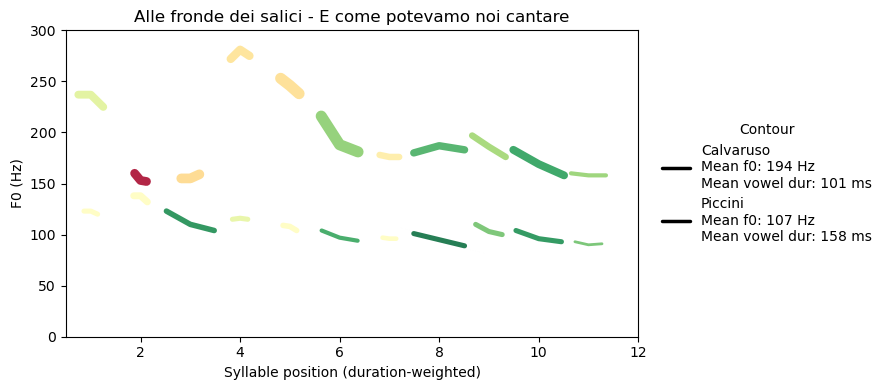

🖼️ Salvato: alle_fronde_e_come_potevamo_noi_cantare_oq.png


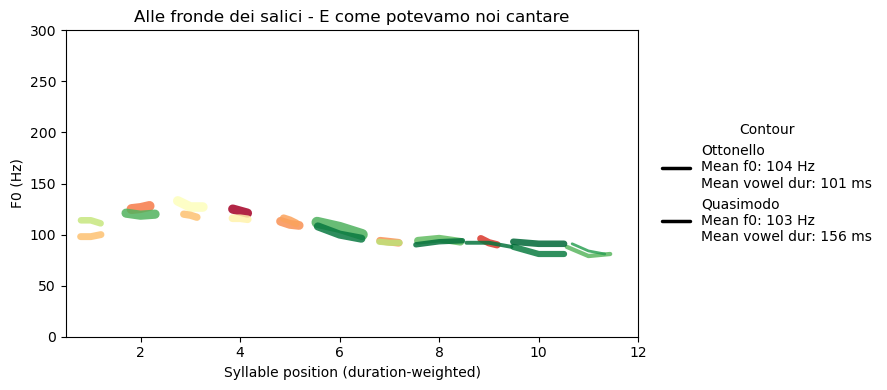

🖼️ Salvato: alle_fronde_crocifisso_sul_palo_cp.png


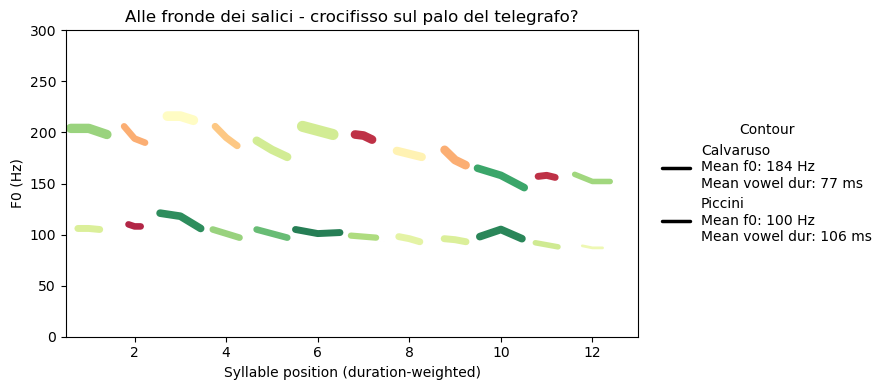

🖼️ Salvato: alle_fronde_crocifisso_sul_palo_oq.png


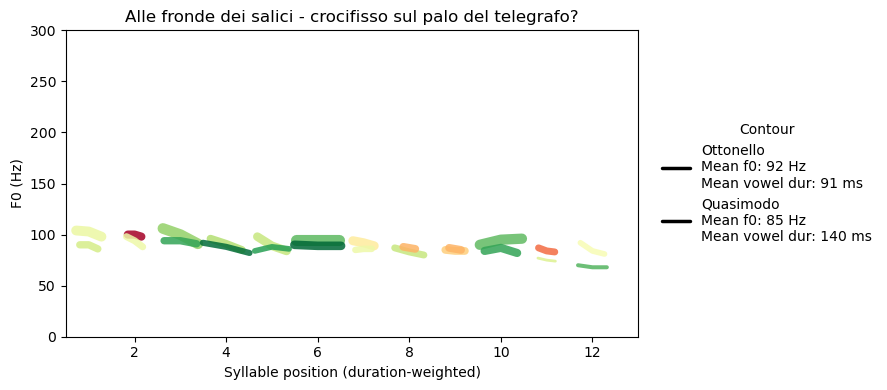

🖼️ Salvato: alle_fronde_oscillavano_lievi_cp.png


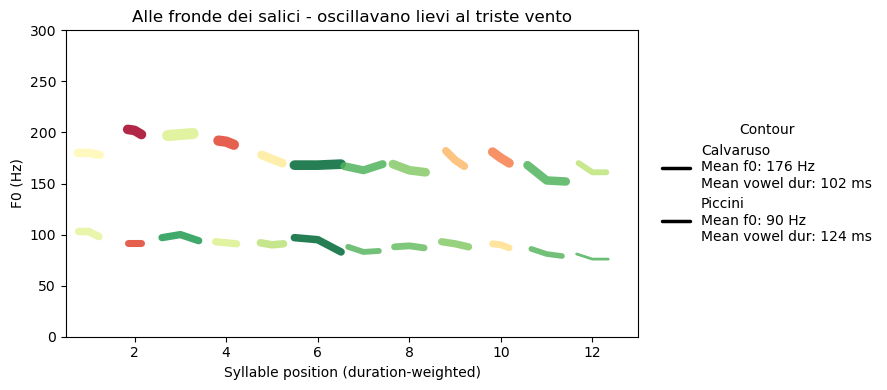

🖼️ Salvato: alle_fronde_oscillavano_lievi_oq.png


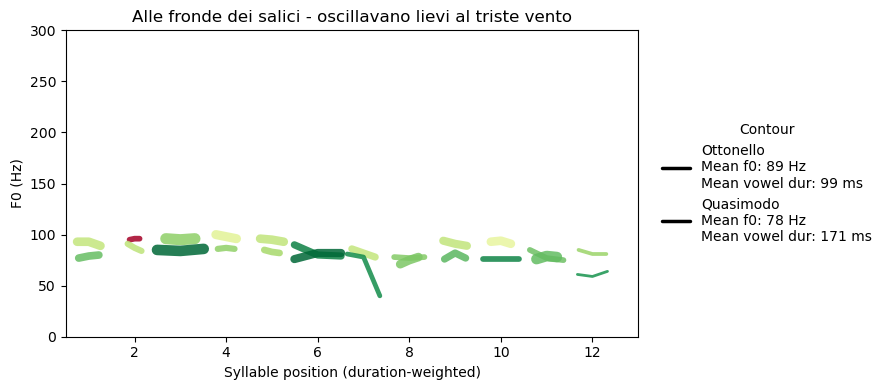

In [27]:
# ============================================================
# AMPER Intonation Visualizer — Segment-based, Vocalic-only Colours
# ------------------------------------------------------------
# - Input: AMPER-style .txt files with:
#       duration [ms]   energy [dB]   fo1 fo2 fo3 [Hz]
#       1   70   71   186 186 188
#       ...
#       values at:
#       t1 t2 t3 ... t_(3*N)
#
# - Output: F0 curves (one or multiple) con:
#       • COLORE = velocità sillabica (rosso = più veloce, verde = più lenta)
#       • SPESSORE = energia sillabica (più dB → linea più spessa)
#       • Asse X in secondi (tempi assoluti, riscalati da AMPER)
#       • f0_min e f0_max impostabili (default: 0–300 Hz)
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import PchipInterpolator


# ---------- Parsing AMPER ----------

def parse_amper_txt(path):
    """
    Parser robusto per file AMPER.

    Si aspetta una struttura del tipo:
        (header con percorso / data)
        duration [ms]   energy [dB]   fo1 fo2 fo3 [Hz]
        1   70   71   186 186 188
        ...
        values at:
        2616 4169 5721 ...

    Ritorna un dict con:
      - 'syll'      : indici sillabici (1..N)
      - 'dur_ms'    : durata sillabica (ms)
      - 'energy'    : energia sillabica (dB)
      - 'f0_points' : array Nx3 con i tre F0 per sillaba
      - 'times_raw' : array (3*N,) con i time-stamp AMPER
    """
    syll_idx = []
    dur_ms = []
    energy = []
    f0_points = []
    times_raw = []

    mode = "start"
    with open(path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            s = line.strip()
            if not s:
                continue

            if "duration [ms]" in s and "fo3" in s:
                mode = "rows"
                continue

            if s.lower().startswith("values at"):
                mode = "times"
                continue

            if mode == "rows":
                parts = s.split()
                if not parts or not parts[0].isdigit():
                    continue
                if len(parts) < 5:
                    continue

                idx = int(parts[0])
                dur = float(parts[1])
                en  = float(parts[2])
                f0_vals = [float(x) for x in parts[-3:]]

                syll_idx.append(idx)
                dur_ms.append(dur)
                energy.append(en)
                f0_points.append(f0_vals)

            elif mode == "times":
                for tok in s.split():
                    if tok.isdigit():
                        times_raw.append(int(tok))

    syll      = np.array(syll_idx if syll_idx else list(range(1, len(dur_ms) + 1)), dtype=int)
    dur_ms    = np.array(dur_ms, dtype=float)
    energy    = np.array(energy, dtype=float)
    f0_points = np.asarray(f0_points, dtype=float)
    times_raw = np.array(times_raw, dtype=float)

    return {
        "syll": syll,
        "dur_ms": dur_ms,
        "energy": energy,
        "f0_points": f0_points,
        "times_raw": times_raw,
    }


# ---------- Time-base (secondi assoluti) ----------

def _amper_timebase(dur_ms, times_raw):
    """
    Costruisce un asse temporale (in secondi) a partire da:
      - dur_ms    : durate sillabiche (ms)
      - times_raw : time-stamp AMPER (unità arbitrarie)

    Strategia:
      1. Normalizza times_raw su [0, 1] (preserva distanze relative).
      2. Riscalibra su [0, SUM(dur_ms)/1000] così che la durata
         complessiva coincida con la somma delle durate sillabiche.
    """
    dur_ms    = np.asarray(dur_ms, float)
    times_raw = np.asarray(times_raw, float)

    total_sec = float(dur_ms.sum()) / 1000.0 if dur_ms.size else 1.0

    if times_raw.size == 0:
        n = max(1, 3 * len(dur_ms))
        return np.linspace(0.0, total_sec, n)

    t_min = np.nanmin(times_raw)
    t_max = np.nanmax(times_raw)
    if not np.isfinite(t_min) or not np.isfinite(t_max) or t_max <= t_min:
        n = max(1, 3 * len(dur_ms))
        return np.linspace(0.0, total_sec, n)

    rel = (times_raw - t_min) / (t_max - t_min)
    return rel * total_sec  # in secondi, non normalizzato 0–1


# ---------- Curve “grezza” ----------

def build_amper_curve(path):
    """
    Converte un file AMPER in una curva F0 “grezza” con 3*N punti in TEMPO ASSOLUTO (s).

    Ritorna:
      - time_raw   : 3*N tempi (s)
      - f0_raw     : 3*N F0
      - speed_raw  : 3*N velocità (sill/sec) associata a ciascun punto
      - energy_raw : 3*N energia (dB) associata a ciascun punto
      - rate_syll  : N velocità sillabiche
    """
    d           = parse_amper_txt(path)
    dur_ms      = d["dur_ms"]
    energy_syll = d["energy"]
    f0_points   = d["f0_points"]
    times_raw   = d["times_raw"]

    n_syll = len(dur_ms)
    if n_syll == 0:
        raise ValueError(f"Nessuna sillaba trovata in: {path}")

    time_raw = _amper_timebase(dur_ms, times_raw)

    if time_raw.size != 3 * n_syll:
        print(
            f"⚠️ AMPER: attesi {3*n_syll} time-stamp, trovati {time_raw.size} in {os.path.basename(path)}. "
            f"Riscaliamo comunque sulla base delle sillabe."
        )
        time_raw = np.linspace(time_raw.min(), time_raw.max(), 3 * n_syll)

    if f0_points.shape[0] != n_syll or f0_points.shape[1] != 3:
        raise ValueError(f"Struttura F0 inattesa in {path}: atteso (N,3), trovato {f0_points.shape}")

    f0_raw = f0_points.reshape(-1)

    dur_sec = dur_ms / 1000.0
    with np.errstate(divide="ignore", invalid="ignore"):
        rate_syll = np.where(dur_sec > 0, 1.0 / dur_sec, 0.0)

    syll_for_point = np.repeat(np.arange(n_syll), 3)
    speed_raw  = rate_syll[syll_for_point]
    energy_raw = energy_syll[syll_for_point]

    return {
        "time_raw":    time_raw,
        "f0_raw":      f0_raw,
        "speed_raw":   speed_raw,
        "energy_raw":  energy_raw,
        "rate_syll":   rate_syll,
        "syll_index":  d["syll"],
        "dur_ms":      dur_ms,
        "energy_syll": energy_syll,
        "source":      path,
    }


# ---------- Smoothing continua opzionale (tempo assoluto) ----------

def smooth_amper_curve(curve, npoints=2000):
    """
    Interpolazione continua (non classica AMPER), in TEMPO ASSOLUTO (s).

    Usa PCHIP (shape-preserving) per F0: niente overshoot,
    curva continua tra le sillabe.
    """
    t  = np.asarray(curve["time_raw"], float)
    f0 = np.asarray(curve["f0_raw"],   float)
    sp = np.asarray(curve["speed_raw"],float)
    en = np.asarray(curve["energy_raw"],float)

    order = np.argsort(t)
    t  = t[order]
    f0 = f0[order]
    sp = sp[order]
    en = en[order]

    uniq_t, uniq_idx = np.unique(t, return_index=True)
    f0u = f0[uniq_idx]
    spu = sp[uniq_idx]
    enu = en[uniq_idx]

    t_smooth = np.linspace(uniq_t.min(), uniq_t.max(), int(max(npoints, 200)))

    try:
        if uniq_t.size >= 3:
            spline_f0 = PchipInterpolator(uniq_t, f0u)
            f0_smooth = spline_f0(t_smooth)
        else:
            f0_smooth = np.interp(t_smooth, uniq_t, f0u)
    except Exception:
        t_smooth  = uniq_t
        f0_smooth = f0u

    speed_smooth  = np.interp(t_smooth, uniq_t, spu)
    energy_smooth = np.interp(t_smooth, uniq_t, enu)

    return {
        "time":            t_smooth,
        "f0":              f0_smooth,
        "speed":           speed_smooth,
        "energy":          energy_smooth,
        "source":          curve.get("source", ""),
        "time_normalized": False,  # sempre tempo assoluto
    }


# ---------- Etichette / legenda ----------

# ---------- Etichette / legenda ----------

def infer_amper_label_from_name(path):
    """
    Ricava un'etichetta "umana" dal nome file.

    Convenzione attesa per i tuoi esempi:
        .../Alba/caproni_uno.txt  → 'Caproni'
        .../Alba/delprete_uno.txt → 'Delprete'
        .../Alba/pacilio_uno.txt  → 'Pacilio'
        .../Alba/tempesta_uno.txt → 'Tempesta'

    Regola:
      - prende lo stem del file (senza estensione)
      - se c'è un underscore, usa la parte PRIMA dell'underscore
      - fa una capitalizzazione "semplice" (prima lettera maiuscola)
    """
    base = os.path.basename(path)
    stem, _ = os.path.splitext(base)

    # prendi tutto ciò che sta prima del primo underscore
    if "_" in stem:
        surname = stem.split("_", 1)[0]
    else:
        surname = stem

    # Capitalizzazione semplice (Caproni, Delprete, ecc.)
    if not surname:
        return "?"

    return surname[0].upper() + surname[1:]


# ---------- Helpers ----------

def _norm_scalar(x, mn, mx):
    if not np.isfinite(x) or not np.isfinite(mn) or not np.isfinite(mx) or mx <= mn:
        return 0.0
    return float((x - mn) / (mx - mn + 1e-12))


# ---------- Plot: modalità "segments" (solo vocali, stile AMPER) ----------

def plot_amper_segments_overlay(curves_raw,
                                labels=None,
                                output_path=None,
                                f0_min=0,
                                f0_max=300,
                                title=None):
    """
    Stile AMPER: solo terzine vocaliche, niente linea tra sillabe.
    Asse X in secondi (assoluti, riscalati da AMPER).
    f0_min default = 0; passare None per auto-range inferiore.
    """
    if not curves_raw:
        print("⚠️ Nessuna curva da plottare.")
        return

    if labels is None:
        labels = [infer_amper_label_from_name(c.get("source", ""))
                  for c in curves_raw]

    all_speed  = np.concatenate([np.asarray(c["speed_raw"],  float) for c in curves_raw])
    all_energy = np.concatenate([np.asarray(c["energy_raw"], float) for c in curves_raw])
    speed_min,  speed_max  = np.nanmin(all_speed),  np.nanmax(all_speed)
    energy_min, energy_max = np.nanmin(all_energy), np.nanmax(all_energy)

    all_f0 = np.concatenate([np.asarray(c["f0_raw"], float) for c in curves_raw])
    if f0_min is None:
        f0_min = float(np.nanmin(all_f0)) - 5.0
    if f0_max is None:
        f0_max = float(np.nanmax(all_f0)) + 5.0

    fig, ax = plt.subplots(figsize=(9, 4))

    for curve, lab in zip(curves_raw, labels):
        t  = np.asarray(curve["time_raw"], float)  # già in secondi
        f0 = np.asarray(curve["f0_raw"],   float)
        sp = np.asarray(curve["speed_raw"],float)
        en = np.asarray(curve["energy_raw"],float)

        n_syll = len(curve["dur_ms"])
        max_syll_from_points = len(f0) // 3
        n_syll = min(n_syll, max_syll_from_points)

        for s_idx in range(n_syll):
            k0 = 3 * s_idx
            k1 = k0 + 1
            k2 = k0 + 2
            seg_t  = t[[k0, k1, k2]]
            seg_f0 = f0[[k0, k1, k2]]

            sp_val = sp[k0]
            en_val = en[k0]

            s_norm = _norm_scalar(sp_val, speed_min,  speed_max)
            e_norm = _norm_scalar(en_val, energy_min, energy_max)
            lw     = 2.0 + 6.0 * e_norm

            ax.plot(
                seg_t,
                seg_f0,
                color=plt.cm.RdYlGn_r(s_norm),
                linewidth=lw,
                alpha=0.9,
            )

        ax.plot([], [], color="black", linewidth=2.5, label=lab)

    ax.set_ylim(f0_min, f0_max)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("F0 (Hz)")
    if title:
        ax.set_title(title)

    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        title="Contour",
        frameon=False,
    )

    plt.tight_layout()
    if output_path:
        plt.savefig(output_path, dpi=150, bbox_inches="tight")
        print(f"🖼️ Salvato: {os.path.basename(output_path)}")
    plt.show()


# ---------- Plot: modalità "smooth" continua (tempo assoluto) ----------

# ---------- Plot: modalità "segments" (solo vocali, stile AMPER) ----------

def plot_amper_segments_overlay(curves_raw,
                                labels=None,
                                output_path=None,
                                f0_min=0,
                                f0_max=300,
                                title=None,
                                centered=False):
    """
    Stile AMPER: solo terzine vocaliche, niente linea tra sillabe.

    Se centered=False:
        - Asse X in secondi (assoluti, riscalati da AMPER).

    Se centered=True:
        - Asse X = posizione sillabica:
            * il CENTRO della sillaba i è sempre a x = i
            * la LARGHEZZA del segmento varia in base alla
              durata reale della sillaba (normalizzata per frase).
        - Quindi sillabe più lunghe = segmenti più larghi,
          sillabe più corte = segmenti più stretti.

    Colori:
      - scala RdYlGn_r = velocità sillabica (più veloce = più rosso)

    Legenda (per curva), ORDINATA PER ALTEZZA MEDIA DI F0 (dall’alto al basso):
      LABEL
      Mean f0: XXX Hz
      Mean vowel dur: YYY ms
    """
    if not curves_raw:
        print("⚠️ Nessuna curva da plottare.")
        return

    # Etichette visibili in legenda (ancora non ordinate)
    if labels is None:
        vis_labels = [infer_amper_label_from_name(c.get("source", ""))
                      for c in curves_raw]
    else:
        vis_labels = list(labels)

    # -------- ORDINA CURVE PER ALTEZZA MEDIA DI F0 (discendente) --------
    curve_stats = []
    for i, c in enumerate(curves_raw):
        f0_vals = np.asarray(c["f0_raw"], float)
        mean_f0 = float(np.nanmean(f0_vals)) if f0_vals.size else np.nan
        curve_stats.append((i, mean_f0))

    # indici ordinati dalla curva con F0 medio più alto alla più bassa
    order = [i for i, _ in sorted(curve_stats, key=lambda x: x[1], reverse=True)]

    # applichiamo l’ordinamento sia alle curve sia alle etichette
    curves_ord = [curves_raw[i] for i in order]
    labels_ord = [vis_labels[i] for i in order]

    # -------- Range globale per velocità, energia, f0 (sulle curve ordinate) --------
    all_speed  = np.concatenate([np.asarray(c["speed_raw"],  float) for c in curves_ord])
    all_energy = np.concatenate([np.asarray(c["energy_raw"], float) for c in curves_ord])
    speed_min,  speed_max  = np.nanmin(all_speed),  np.nanmax(all_speed)
    energy_min, energy_max = np.nanmin(all_energy), np.nanmax(all_energy)

    all_f0 = np.concatenate([np.asarray(c["f0_raw"], float) for c in curves_ord])
    if f0_min is None:
        f0_min = float(np.nanmin(all_f0)) - 5.0
    if f0_max is None:
        f0_max = float(np.nanmax(all_f0)) + 5.0

    # Per xlim in modalità centered: max numero sillabe
    max_n_syll = 0
    for c in curves_ord:
        n_syll = min(len(c["dur_ms"]), len(c["f0_raw"]) // 3)
        max_n_syll = max(max_n_syll, n_syll)

    fig, ax = plt.subplots(figsize=(9, 4))

    # -------- Loop sulle curve in ordine di ALTEZZA MEDIA --------
    for curve, lab in zip(curves_ord, labels_ord):
        t   = np.asarray(curve["time_raw"],   float)  # già in secondi
        f0  = np.asarray(curve["f0_raw"],     float)
        sp  = np.asarray(curve["speed_raw"],  float)
        en  = np.asarray(curve["energy_raw"], float)
        dur = np.asarray(curve["dur_ms"],     float)

        n_syll = len(dur)
        max_syll_from_points = len(f0) // 3
        n_syll = min(n_syll, max_syll_from_points)

        # Normalizzazione durate per la modalità centrata
        if centered and n_syll > 0:
            m_dur = np.nanmean(dur)
            if (not np.isfinite(m_dur)) or m_dur <= 0:
                m_dur = 1.0
            dur_norm = dur / m_dur          # >1 = più lunga della media
            dur_norm = np.clip(dur_norm, 0.3, 1.7)   # evita estremi assoluti
            base_width = 0.6                # “larghezza media” in unità sillabiche
        else:
            dur_norm = None
            base_width = None

        for s_idx in range(n_syll):
            k0 = 3 * s_idx
            k1 = k0 + 1
            k2 = k0 + 2

            seg_f0 = f0[[k0, k1, k2]]

            # Asse X: tempo assoluto vs posizione sillabica centrata (duration-weighted)
            if centered:
                center = s_idx + 1  # sillabe numerate da 1 a N

                if dur_norm is not None and s_idx < dur_norm.size:
                    width = base_width * dur_norm[s_idx]
                else:
                    width = 0.6

                half_w = width / 2.0
                seg_x = np.array([center - half_w, center, center + half_w])
            else:
                seg_x = t[[k0, k1, k2]]

            sp_val = sp[k0]
            en_val = en[k0]

            s_norm = _norm_scalar(sp_val, speed_min,  speed_max)
            e_norm = _norm_scalar(en_val, energy_min, energy_max)
            lw     = 2.0 + 6.0 * e_norm

            color = plt.cm.RdYlGn_r(s_norm)

            ax.plot(
                seg_x,
                seg_f0,
                color=color,
                linewidth=lw,
                alpha=0.85,
                solid_capstyle="round",
                solid_joinstyle="round",
                antialiased=True,
            )

        # Statistiche globali per la legenda (coerenti con l’ordinamento)
        mean_f0  = float(np.nanmean(f0))
        mean_dur = float(np.nanmean(curve["dur_ms"])) if len(curve["dur_ms"]) else np.nan

        legend_lab = (
            f"{lab}\n"
            f"Mean f0: {mean_f0:.0f} Hz\n"
            f"Mean vowel dur: {mean_dur:.0f} ms"
        )

        ax.plot([], [], color="black", linewidth=2.5,
                solid_capstyle="round", solid_joinstyle="round",
                label=legend_lab)

    ax.set_ylim(f0_min, f0_max)

    if centered:
        # margine a destra per non schiacciare l’ultima sillaba
        ax.set_xlim(0.5, max_n_syll + 1.0)
        ax.set_xlabel("Syllable position (duration-weighted)")
    else:
        ax.set_xlabel("Time (s)")

    ax.set_ylabel("F0 (Hz)")
    if title:
        ax.set_title(title)

    ax.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        title="Contour",
        frameon=False,
    )

    plt.tight_layout()
    if output_path:
        plt.savefig(output_path, dpi=150, bbox_inches="tight")
        print(f"🖼️ Salvato: {os.path.basename(output_path)}")
    plt.show()


# ---------- Wrapper principale ----------

def plot_amper_files(txt_paths,
                     output_path=None,
                     f0_min=0,
                     f0_max=300,
                     title=None,
                     npoints=2000,
                     labels=None,
                     mode="segments",
                     centered=False):
    """
    Wrapper principale.

    - f0_min default = 0 (ymin), f0_max default = 300.
      → passa f0_min=None per auto-range inferiore.
    - mode:
        * "segments" (stile AMPER, default)
        * "smooth"   (curva continua interpolata, tempo assoluto)
    - centered:
        * solo per mode="segments":
          False → asse X in secondi
          True  → asse X in posizione sillabica (duration-weighted)
    """
    base_curves = []
    for p in txt_paths:
        if not os.path.exists(p):
            print(f"⚠️ File AMPER mancante: {p}")
            continue
        base_curves.append(build_amper_curve(p))

    if not base_curves:
        print("⚠️ Nessuna curva AMPER valida.")
        return

    if mode == "smooth":
        curves = [smooth_amper_curve(c, npoints=npoints) for c in base_curves]
        plot_amper_overlay(
            curves_smooth=curves,
            labels=labels,
            output_path=output_path,
            f0_min=f0_min,
            f0_max=f0_max,
            title=title,
        )
        return curves

    # mode == "segments"
    plot_amper_segments_overlay(
        curves_raw=base_curves,
        labels=labels,
        output_path=output_path,
        f0_min=f0_min,
        f0_max=f0_max,
        title=title,
        centered=centered,
    )
    return base_curves


# ------------------------------------------------------------
# Uso rapido in Jupyter (tempi assoluti):
#
# %matplotlib inline
# curves = plot_amper_files(
#     [
#         "/Users/Federico/.../canaletti_due.txt",
#         "/Users/Federico/.../penna_due.txt",
#         "/Users/Federico/.../pozzani_due.txt",
#     ],
#     title="Confronto contorni AMPER — La vita",
#     output_path="/Users/Federico/.../la_vita_overlay_segments.png",
#     f0_min=0,      # ymin manuale
#     f0_max=300,    # ymax manuale
#     mode="segments",
# )
# ------------------------------------------------------------


# ------------------------------------------------------------
# Uso rapido in Jupyter (decommenta ed adatta i percorsi):

# %matplotlib inline
curves = plot_amper_files(
    [
        "/Users/Federico/Desktop/materiali_tesi/Convegni/FYP/amperfox_amperdat/Alle_fronde/calvaruso_uno.txt",
        "/Users/Federico/Desktop/materiali_tesi/Convegni/FYP/amperfox_amperdat/Alle_fronde/piccini_uno.txt",
    ],
    title="Alle fronde dei salici - E come potevamo noi cantare",
    output_path="/Users/Federico/Desktop/materiali_tesi/Convegni/FYP/alle_fronde_e_come_potevamo_noi_cantare_cp.png",
    f0_min=0,
    f0_max=300,
    mode="segments",
    centered=True,   # <<— centratura sillabica, duration-weighted
)
# ------------------------------------------------------------

# %matplotlib inline
curves = plot_amper_files(
    [
        "/Users/Federico/Desktop/materiali_tesi/Convegni/FYP/amperfox_amperdat/Alle_fronde/ottonello_uno.txt",
        "/Users/Federico/Desktop/materiali_tesi/Convegni/FYP/amperfox_amperdat/Alle_fronde/quasimodo_uno.txt",
    ],
    title="Alle fronde dei salici - E come potevamo noi cantare",
    output_path="/Users/Federico/Desktop/materiali_tesi/Convegni/FYP/alle_fronde_e_come_potevamo_noi_cantare_oq.png",
    f0_min=0,
    f0_max=300,
    mode="segments",
    centered=True,   # <<— centratura sillabica, duration-weighted
)
# ------------------------------------------------------------

# %matplotlib inline
curves = plot_amper_files(
    [
        "/Users/Federico/Desktop/materiali_tesi/Convegni/FYP/amperfox_amperdat/Alle_fronde/calvaruso_due.txt",
        "/Users/Federico/Desktop/materiali_tesi/Convegni/FYP/amperfox_amperdat/Alle_fronde/piccini_due.txt",
    ],
    title="Alle fronde dei salici - crocifisso sul palo del telegrafo?",
    output_path="/Users/Federico/Desktop/materiali_tesi/Convegni/FYP/alle_fronde_crocifisso_sul_palo_cp.png",
    f0_min=0,
    f0_max=300,
    mode="segments",
    centered=True,   # <<— centratura sillabica, duration-weighted
)
# ------------------------------------------------------------

# %matplotlib inline
curves = plot_amper_files(
    [
        "/Users/Federico/Desktop/materiali_tesi/Convegni/FYP/amperfox_amperdat/Alle_fronde/ottonello_due.txt",
        "/Users/Federico/Desktop/materiali_tesi/Convegni/FYP/amperfox_amperdat/Alle_fronde/quasimodo_due.txt",
    ],
    title="Alle fronde dei salici - crocifisso sul palo del telegrafo?",
    output_path="/Users/Federico/Desktop/materiali_tesi/Convegni/FYP/alle_fronde_crocifisso_sul_palo_oq.png",
    f0_min=0,
    f0_max=300,
    mode="segments",
    centered=True,   # <<— centratura sillabica, duration-weighted
)
# ------------------------------------------------------------

# %matplotlib inline
curves = plot_amper_files(
    [
        "/Users/Federico/Desktop/materiali_tesi/Convegni/FYP/amperfox_amperdat/Alle_fronde/calvaruso_tre.txt",
        "/Users/Federico/Desktop/materiali_tesi/Convegni/FYP/amperfox_amperdat/Alle_fronde/piccini_tre.txt",
    ],
    title="Alle fronde dei salici - oscillavano lievi al triste vento",
    output_path="/Users/Federico/Desktop/materiali_tesi/Convegni/FYP/alle_fronde_oscillavano_lievi_cp.png",
    f0_min=0,
    f0_max=300,
    mode="segments",
    centered=True,   # <<— centratura sillabica, duration-weighted
)
# ------------------------------------------------------------

# %matplotlib inline
curves = plot_amper_files(
    [
        "/Users/Federico/Desktop/materiali_tesi/Convegni/FYP/amperfox_amperdat/Alle_fronde/ottonello_tre.txt",
        "/Users/Federico/Desktop/materiali_tesi/Convegni/FYP/amperfox_amperdat/Alle_fronde/quasimodo_tre.txt",
    ],
    title="Alle fronde dei salici - oscillavano lievi al triste vento",
    output_path="/Users/Federico/Desktop/materiali_tesi/Convegni/FYP/alle_fronde_oscillavano_lievi_oq.png",
    f0_min=0,
    f0_max=300,
    mode="segments",
    centered=True,   # <<— centratura sillabica, duration-weighted
)
# ------------------------------------------------------------